In [12]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import math
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler, PowerTransformer, QuantileTransformer, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, GridSearchCV, RepeatedStratifiedKFold
#import autogluon as ag

# Models
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier, AdaBoostClassifier,RandomForestClassifier,ExtraTreesClassifier,VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
from optuna.integration import LightGBMPruningCallback

import torch
import torch.nn as nn
import torch.optim as optim
if torch.cuda.is_available():
    device = torch.device("cuda")  
else:
    device = torch.device("cpu")   
    
# Metrics 
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,auc, roc_auc_score, roc_curve, make_scorer, f1_score

import warnings
warnings.filterwarnings('ignore')

In [13]:
train = pd.read_csv('/kaggle/input/playground-series-s4e2/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s4e2/test.csv')
sample_submission = pd.read_csv('/kaggle/input/playground-series-s4e2/sample_submission.csv',index_col='id')

train.drop('id',axis=1,inplace=True)
test.drop('id',axis=1,inplace=True)
train['BMI'] = train['Weight'] / (train['Height']**2)
test['BMI'] = test['Weight'] / (test['Height']**2)

In [10]:
train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [11]:
test.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,20758,Male,26.899886,1.848294,120.644178,yes,yes,2.938616,3.000000,Sometimes,no,2.825629,no,0.855400,0.000000,Sometimes,Public_Transportation
1,20759,Female,21.000000,1.600000,66.000000,yes,yes,2.000000,1.000000,Sometimes,no,3.000000,no,1.000000,0.000000,Sometimes,Public_Transportation
2,20760,Female,26.000000,1.643355,111.600553,yes,yes,3.000000,3.000000,Sometimes,no,2.621877,no,0.000000,0.250502,Sometimes,Public_Transportation
3,20761,Male,20.979254,1.553127,103.669116,yes,yes,2.000000,2.977909,Sometimes,no,2.786417,no,0.094851,0.000000,Sometimes,Public_Transportation
4,20762,Female,26.000000,1.627396,104.835346,yes,yes,3.000000,3.000000,Sometimes,no,2.653531,no,0.000000,0.741069,Sometimes,Public_Transportation


In [12]:
# train.drop('id',axis=1,inplace=True)
# test.drop('id',axis=1,inplace=True)
print('The shape of the train data:', train.shape)
print('The shape of the test data:', test.shape)

The shape of the train data: (20758, 17)
The shape of the test data: (13840, 16)


In [13]:
train.describe().T\
    .style.bar(subset=['mean'], color=px.colors.qualitative.G10[2])\
    .background_gradient(subset=['std'], cmap='Blues')\
    .background_gradient(subset=['50%'], cmap='BuGn')

,count,mean,std,min,25%,50%,75%,max
Age,20758.000000,23.841804,5.688072,14.000000,20.000000,22.815416,26.000000,61.000000
Height,20758.000000,1.700245,0.087312,1.450000,1.631856,1.700000,1.762887,1.975663
Weight,20758.000000,87.887768,26.379443,39.000000,66.000000,84.064875,111.600553,165.057269
FCVC,20758.000000,2.445908,0.533218,1.000000,2.000000,2.393837,3.000000,3.000000
NCP,20758.000000,2.761332,0.705375,1.000000,3.000000,3.000000,3.000000,4.000000
CH2O,20758.000000,2.029418,0.608467,1.000000,1.792022,2.000000,2.549617,3.000000
FAF,20758.000000,0.981747,0.838302,0.000000,0.008013,1.000000,1.587406,3.000000
TUE,20758.000000,0.616756,0.602113,0.000000,0.000000,0.573887,1.000000,2.000000


In [14]:
def summary(df):
    sum = pd.DataFrame(df.dtypes, columns=['dtypes'])
    sum['missing#'] = df.isna().sum()
    sum['missing%'] = (df.isna().sum())/len(df)
    sum['uniques'] = df.nunique().values
    sum['count'] = df.count().values
    #sum['skew'] = df.skew().values
    return sum

In [15]:
summary(train).style.background_gradient(cmap='Blues')

,dtypes,missing#,missing%,uniques,count
Gender,object,0,0.000000,2,20758
Age,float64,0,0.000000,1703,20758
Height,float64,0,0.000000,1833,20758
Weight,float64,0,0.000000,1979,20758
family_history_with_overweight,object,0,0.000000,2,20758
FAVC,object,0,0.000000,2,20758
FCVC,float64,0,0.000000,934,20758
NCP,float64,0,0.000000,689,20758
CAEC,object,0,0.000000,4,20758
SMOKE,object,0,0.000000,2,20758


In [16]:
summary(test).style.background_gradient(cmap='Blues')

,dtypes,missing#,missing%,uniques,count
Gender,object,0,0.000000,2,13840
Age,float64,0,0.000000,1539,13840
Height,float64,0,0.000000,1739,13840
Weight,float64,0,0.000000,1798,13840
family_history_with_overweight,object,0,0.000000,2,13840
FAVC,object,0,0.000000,2,13840
FCVC,float64,0,0.000000,828,13840
NCP,float64,0,0.000000,649,13840
CAEC,object,0,0.000000,4,13840
SMOKE,object,0,0.000000,2,13840


In [8]:
conts = ['Age', 'Height', 'Weight','BMI','FCVC','NCP','CH2O','FAF','TUE']
cats = ['Gender','family_history_with_overweight','FAVC',  'CAEC', 'SMOKE', 'SCC','CALC', 'MTRANS']
target = 'NObeyesdad'

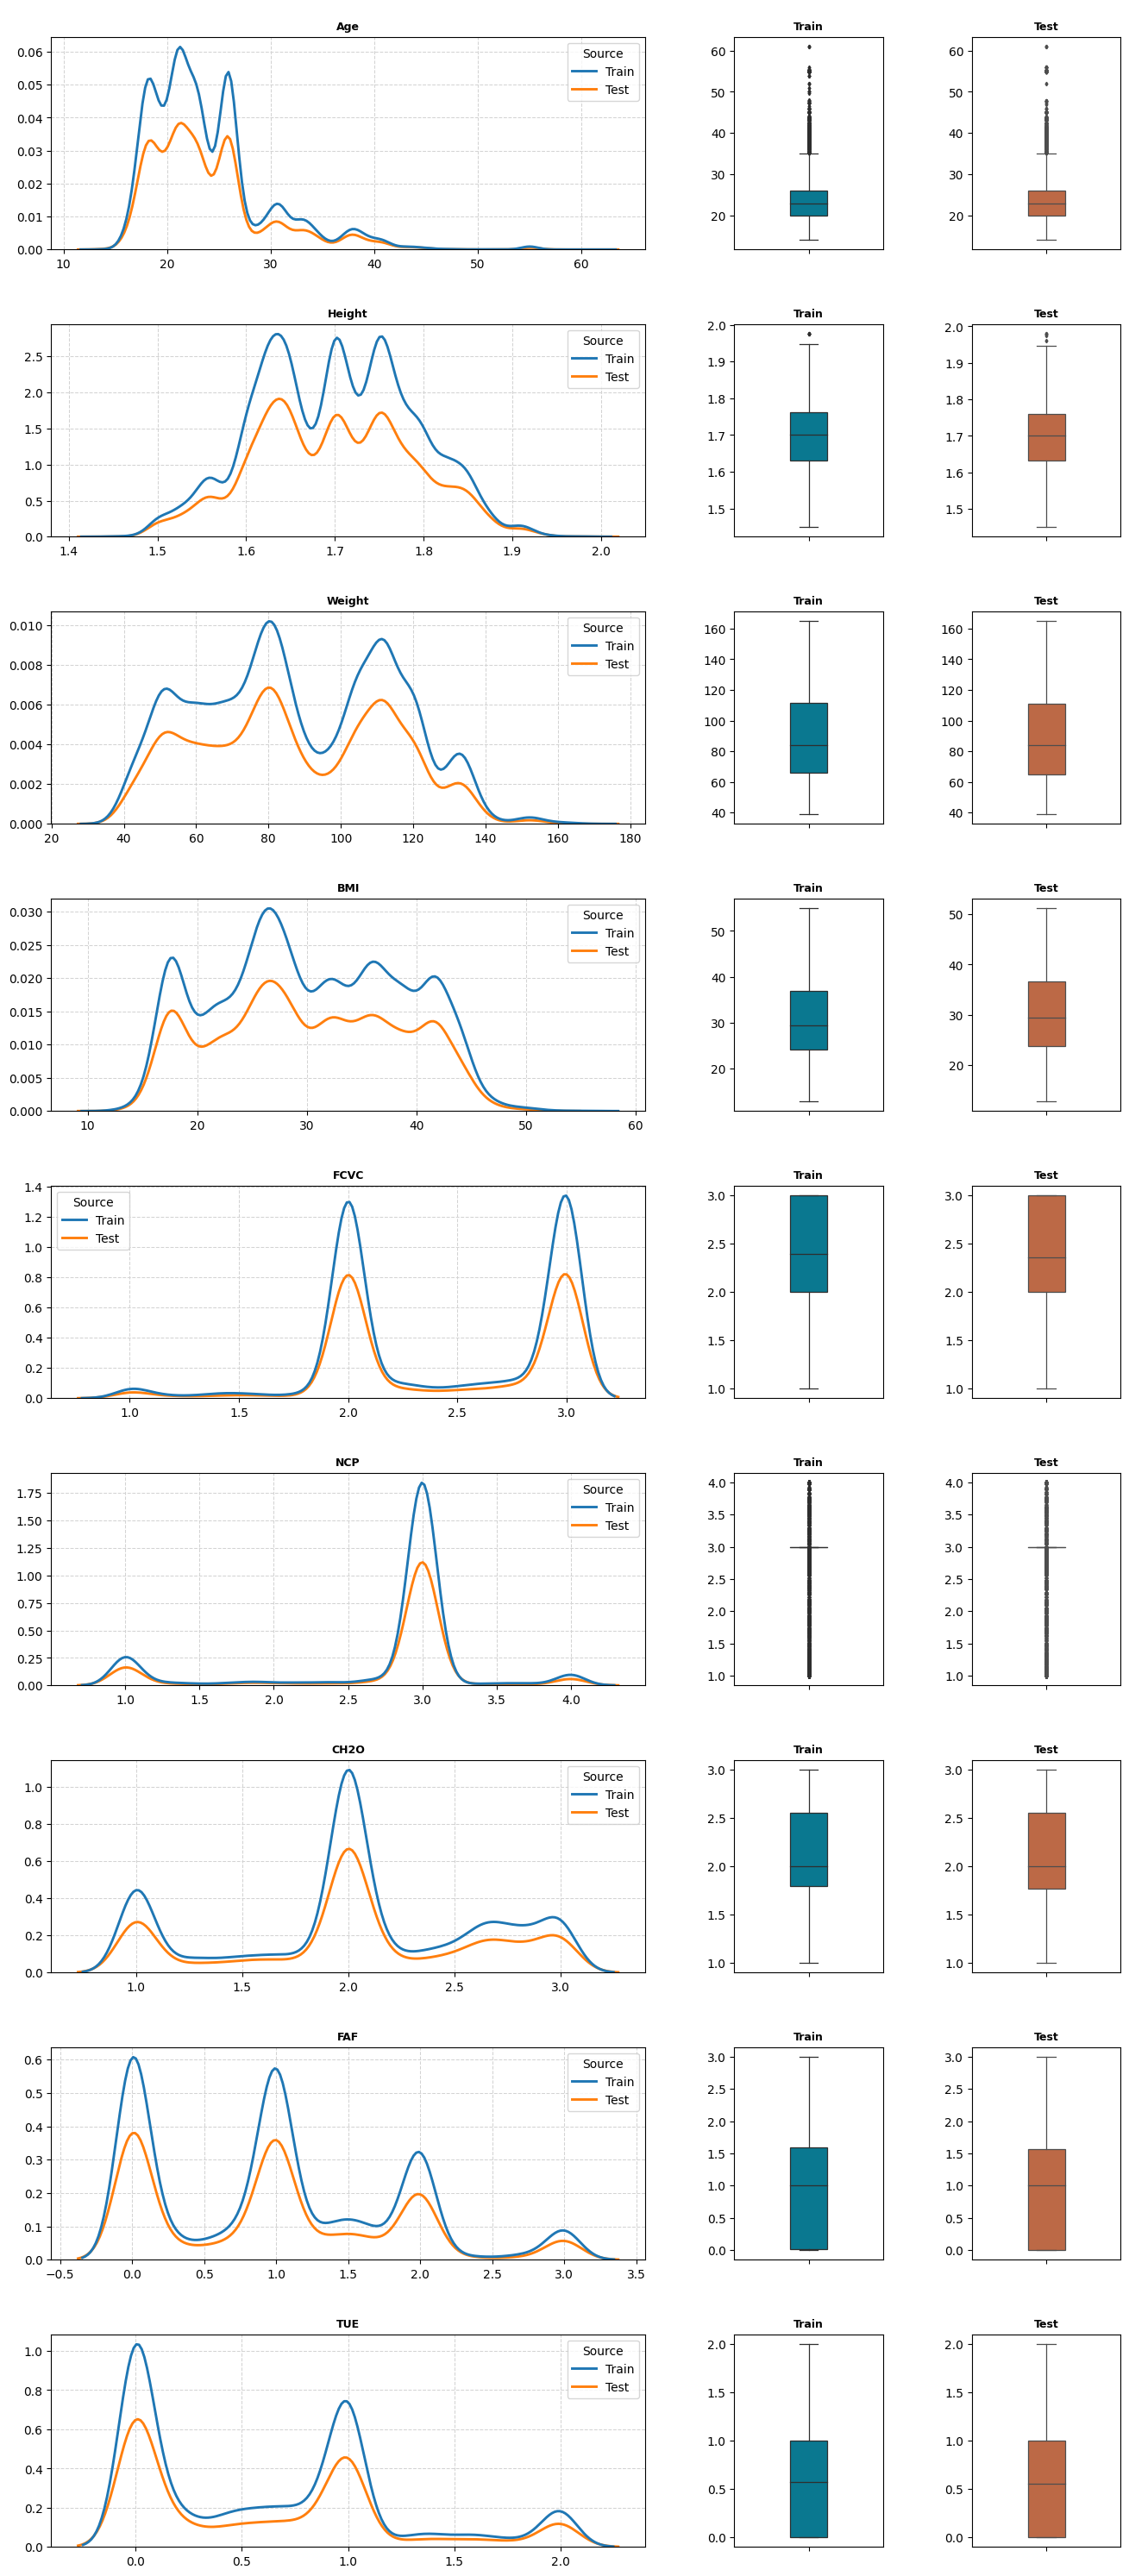

In [32]:
df = pd.concat([train[conts].assign(Source = 'Train'), 
                test[conts].assign(Source = 'Test')], 
               axis=0, ignore_index = True);

fig, axes = plt.subplots(len(conts), 3 ,figsize = (16, len(conts) * 4.2), 
                         gridspec_kw = {'hspace': 0.35, 'wspace': 0.3, 'width_ratios': [0.80, 0.20, 0.20]});

for i,col in enumerate(conts):
    ax = axes[i,0];
    sns.kdeplot(data = df[[col, 'Source']], x = col, hue = 'Source', ax = ax, linewidth = 2.1)
    ax.set_title(f"\n{col}",fontsize = 9, fontweight= 'bold');
    ax.grid(visible=True, which = 'both', linestyle = '--', color='lightgrey', linewidth = 0.75);
    ax.set(xlabel = '', ylabel = '');
    ax = axes[i,1];
    sns.boxplot(data = df.loc[df.Source == 'Train', [col]], y = col, width = 0.25,saturation = 0.90, linewidth = 0.90, fliersize= 2.25, color = '#037d97',
                ax = ax);
    ax.set(xlabel = '', ylabel = '');
    ax.set_title(f"Train",fontsize = 9, fontweight= 'bold');

    ax = axes[i,2];
    sns.boxplot(data = df.loc[df.Source == 'Test', [col]], y = col, width = 0.25, fliersize= 2.25,
                saturation = 0.6, linewidth = 0.90, color = '#E4591E',
                ax = ax); 
    ax.set(xlabel = '', ylabel = '');
    ax.set_title(f"Test",fontsize = 9, fontweight= 'bold');

plt.tight_layout()

In [35]:
def plot_count(df,columns,n_cols,hue):
    '''
    # Function to genear countplot
    df: total data
    columns: category variables
    n_cols: num of cols
    '''
    n_rows = (len(columns) - 1) // n_cols + 1
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(17, 4 * n_rows))
    ax = ax.flatten()
    
    for i, column in enumerate(columns):
        sns.countplot(data=df, x=column, ax=ax[i],hue=hue)

        # Titles
        ax[i].set_title(f'{column} Counts', fontsize=18)
        ax[i].set_xlabel(None, fontsize=16)
        ax[i].set_ylabel(None, fontsize=16)
        ax[i].tick_params(axis='x', rotation=10)

        for p in ax[i].patches:
            value = int(p.get_height())
            ax[i].annotate(f'{value:.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                           ha='center', va='bottom', fontsize=9)

    ylim_top = ax[i].get_ylim()[1]
    ax[i].set_ylim(top=ylim_top * 1.1)
    for i in range(len(columns), len(ax)):
        ax[i].axis('off')

    # fig.suptitle(plotname, fontsize=25, fontweight='bold')
    plt.tight_layout()
    plt.show()

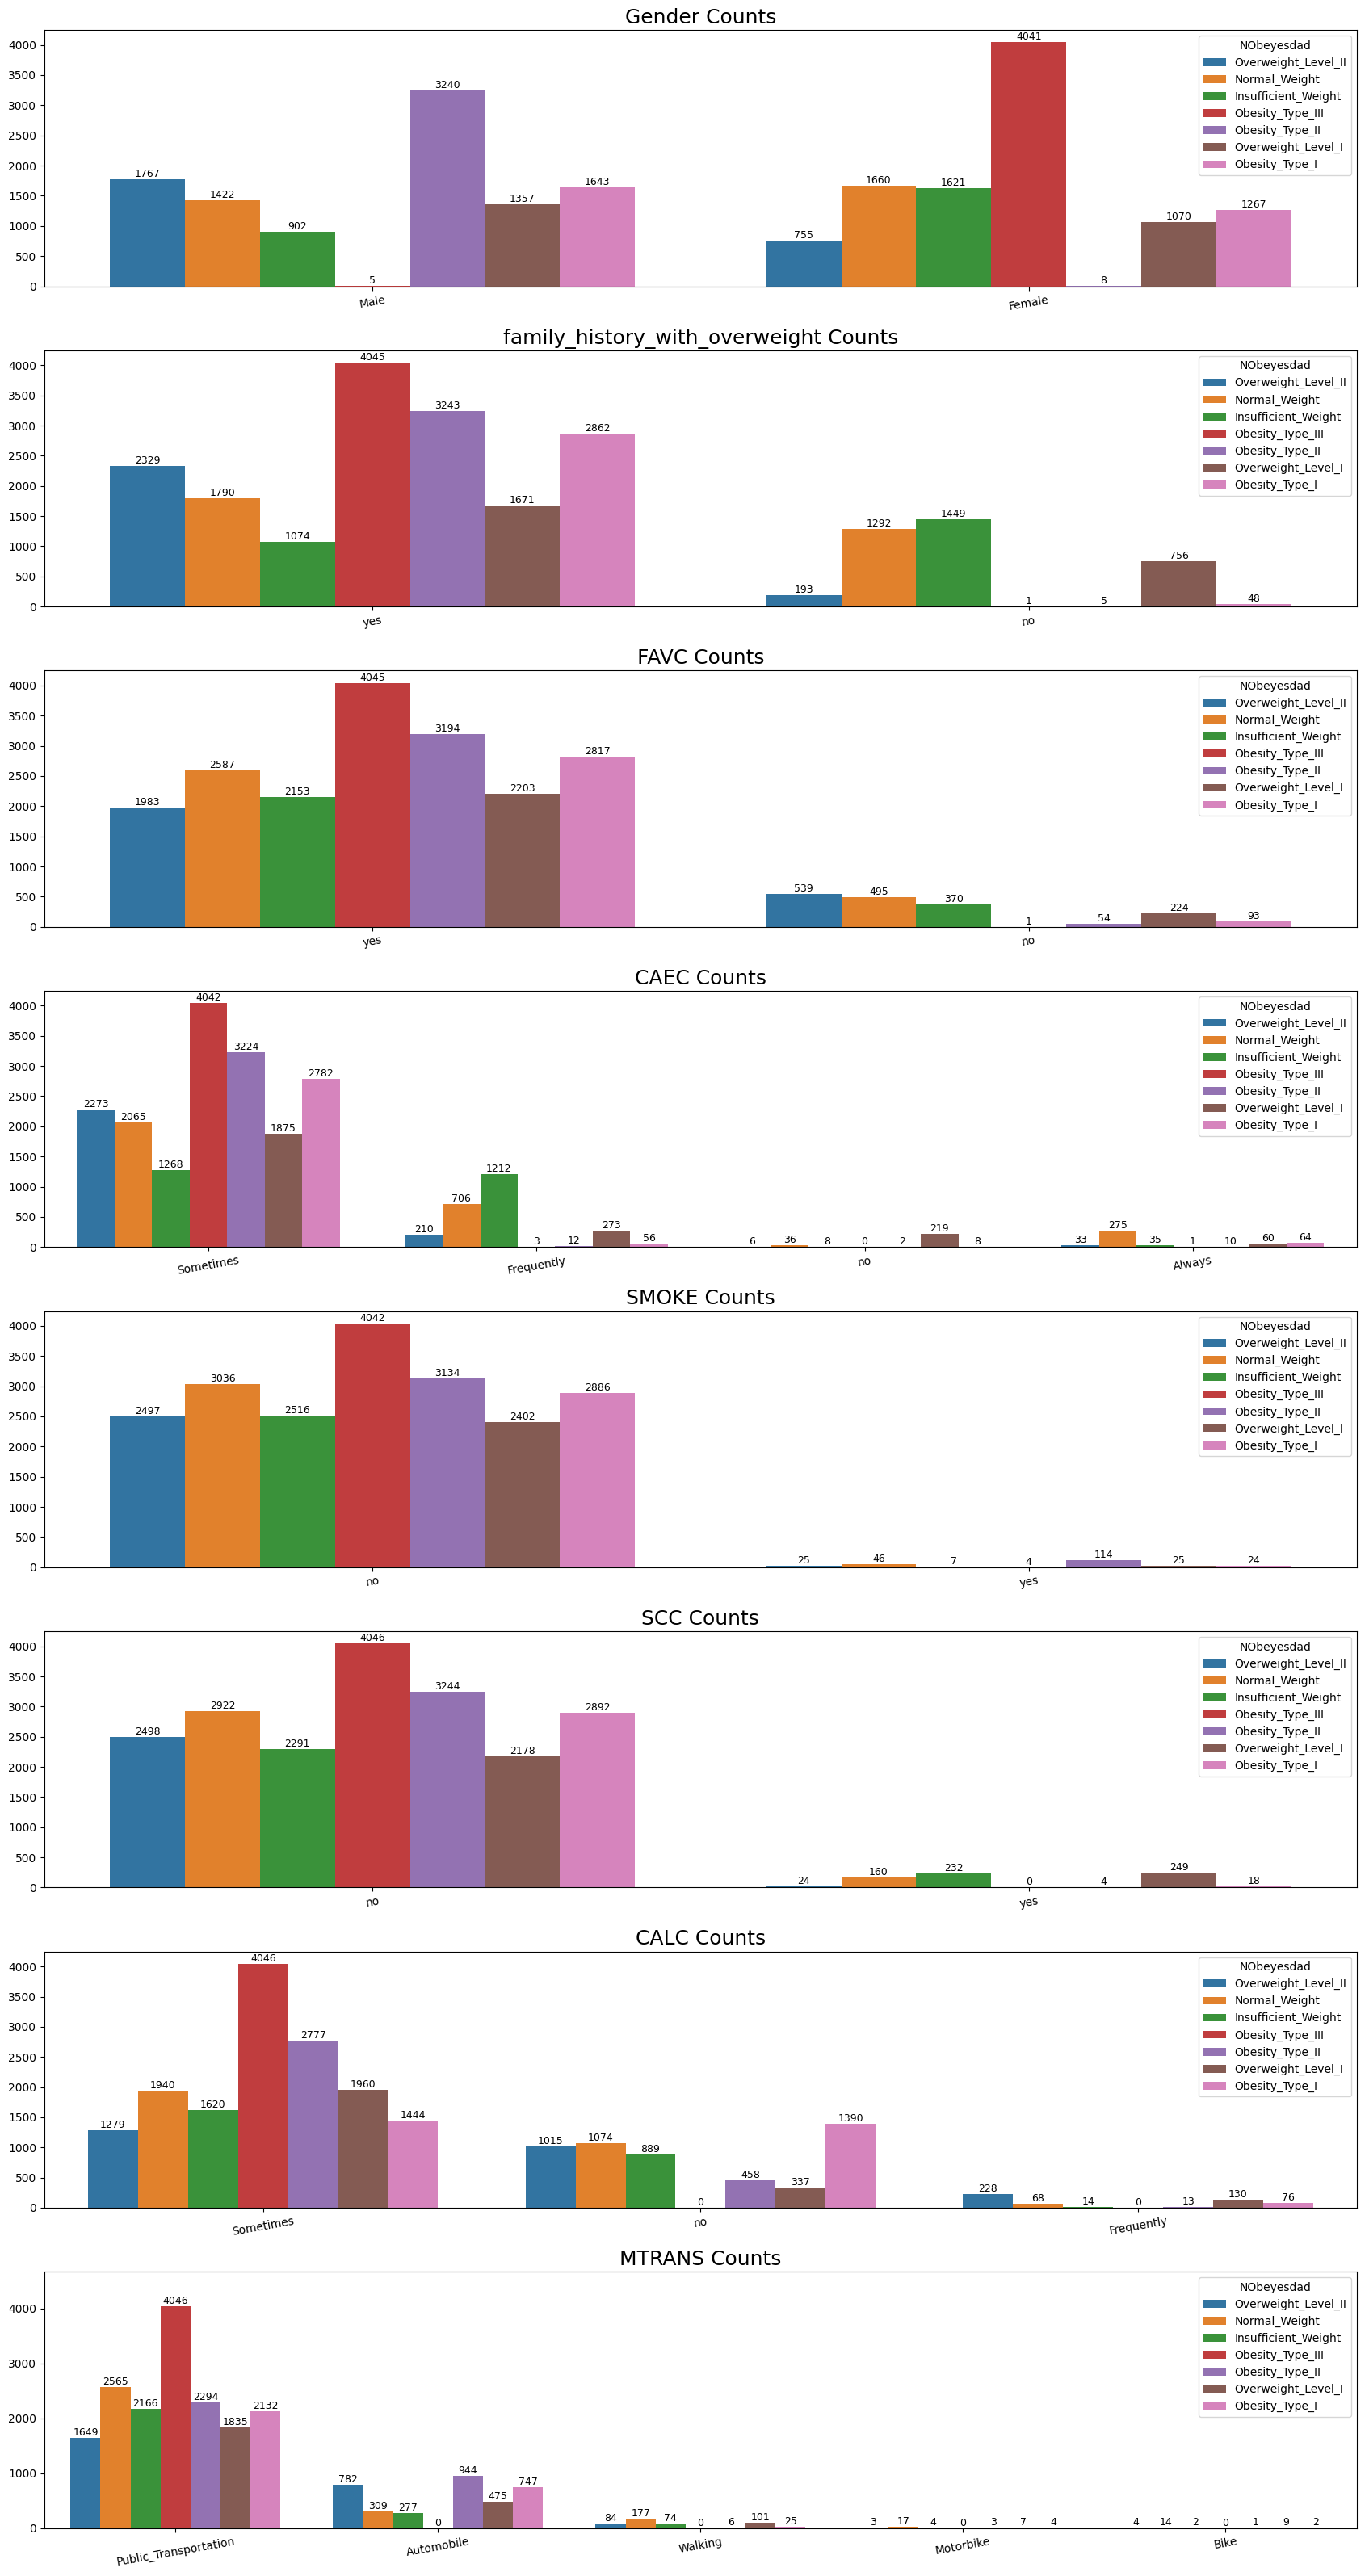

In [38]:
plot_count(train,cats,1,target)

In [39]:
def chi_squared_test(df, input_var, target_var, significance_level=0.05):
    contingency_table = pd.crosstab(df[input_var], df[target_var])
    chi2, p, _, _ = stats.chi2_contingency(contingency_table)
    
    if p < significance_level:
        print(f'\033[32m{input_var} has a significant relationship with the target variable.\033[0m') 
    else:
        print(f'\033[31m{input_var} does not have a significant relationship with the target variable.\033[0m')  


In [40]:
for i in cats:
    chi_squared_test(train, i, target)

Gender has a significant relationship with the target variable.
family_history_with_overweight has a significant relationship with the target variable.
FAVC has a significant relationship with the target variable.
CAEC has a significant relationship with the target variable.
SMOKE has a significant relationship with the target variable.
SCC has a significant relationship with the target variable.
CALC has a significant relationship with the target variable.
MTRANS has a significant relationship with the target variable.


In [10]:
learningMetadata = {}

In [9]:
def encoder(df, binCols, ohe_cols, training):
    # Label Encoding for binary cols
    le = LabelEncoder()    
    for col in binCols:
        df[col] = le.fit_transform(df[col])
    
    df = pd.get_dummies(df, columns = ohe_cols)
    df["CAEC"] = df["CAEC"].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
    df["CALC"] = df["CALC"].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
    if training == True:
        df['NObeyesdad'] = df['NObeyesdad'].map({'Overweight_Level_II':0, 'Normal_Weight':1, 'Insufficient_Weight':2,
       'Obesity_Type_III':3, 'Obesity_Type_II':4, 'Overweight_Level_I':5,
       'Obesity_Type_I':6})
    return df

In [14]:
unique_counts = train.nunique()

binary_columns = unique_counts[unique_counts == 2].index.tolist()
OHE_Cols = ['MTRANS']

In [15]:
test = encoder(test, binary_columns, OHE_Cols, training=False)
train = encoder(train, binary_columns, OHE_Cols,True)

In [16]:
cols = ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'BMI', 'MTRANS_Automobile', 'MTRANS_Bike',
       'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']

In [17]:
class learner():
    
    def __init__(self,df_train,df_test, target, model, selected_features, note):
        self.X_train = df_train[selected_features]
        self.Y_train = df_train[target]
        self.X_test = df_test[selected_features]
        self.model = model
        self.note = note

    
    def fit(self):
        skf = StratifiedKFold(shuffle=True, random_state=1)
        self.acc_stratified = []
        self.model_preds_test = []
        self.model_preds_oof = []
        self.oof_y = []
        self.models = []
    
    
    
        for i,(train_index, test_index) in enumerate(skf.split(self.X_train, self.Y_train)):
            print('---------------------------------------------------------------')
            x_train_fold, x_test_fold = self.X_train.iloc[train_index], self.X_train.iloc[test_index]
            y_train_fold, y_test_fold = self.Y_train[train_index], self.Y_train[test_index]
        
        
            self.model.fit(x_train_fold, y_train_fold)
            model_oof_preds = self.model.predict(x_test_fold)
            accScore = accuracy_score(y_test_fold,model_oof_preds)
            self.models.append(self.model)
        

            self.model_preds_test.append(self.model.predict(self.X_test))
            self.model_preds_oof.append(model_oof_preds)
            self.oof_y.append(y_test_fold)

            print(f"Fold, {i+1}, ==> {self.note} oof ACC score is ==> {accScore}")
            self.acc_stratified.append(accScore)
    
        print('---------------------------------------------------------------')
        avgAcc = np.array(self.acc_stratified).mean()
        print('Average Accuracy of model is:', avgAcc)
        learningMetadata[self.note] = {'avgAcc': avgAcc}
        print('-------------------------------------------------------------')
        print(pd.DataFrame.from_dict(learningMetadata).T)
    
    def subm(self,file):
        preds = [np.argmax(np.bincount(np.array(col))) + 1 for col in zip(*self.model_preds_test)]
        preds = [key for value in preds for key, val in {'Overweight_Level_II':1, 'Normal_Weight':2, 'Insufficient_Weight':3,
           'Obesity_Type_III':4, 'Obesity_Type_II':5, 'Overweight_Level_I':6,'Obesity_Type_I':7}.items() if val == value]
        sample_submission[target] = preds
        sample_submission.to_csv('sub-'+file+'.csv')
        
    def fi(self):
        combined_importances = np.zeros(len(self.models[0].feature_importances_))

        for model in self.models:
            combined_importances += model.feature_importances_

        combined_importances /= len(self.models)
        
        fi = pd.DataFrame({'cols':self.X_train.columns, 'imp':combined_importances}
                       ).sort_values('imp', ascending=False)

        fi.plot('cols', 'imp', 'barh', figsize=(12,7), legend=False)

In [61]:
rf = learner(train,test,target,RandomForestClassifier(),cols,'BasicRF-Allcols')
rf.fit()

---------------------------------------------------------------
Fold, 1, ==> BasicRF-Allcols oof ACC score is ==> 0.9007707129094412
---------------------------------------------------------------
Fold, 2, ==> BasicRF-Allcols oof ACC score is ==> 0.8995664739884393
---------------------------------------------------------------
Fold, 3, ==> BasicRF-Allcols oof ACC score is ==> 0.9087186897880539
---------------------------------------------------------------
Fold, 4, ==> BasicRF-Allcols oof ACC score is ==> 0.9019513370272224
---------------------------------------------------------------
Fold, 5, ==> BasicRF-Allcols oof ACC score is ==> 0.8985786557456035
---------------------------------------------------------------
Average Accuracy of model is: 0.9019171738917521
-------------------------------------------------------------
                   avgAcc
BasicRF-Allcols  0.901917


In [55]:
rf.subm('RF_Basic')

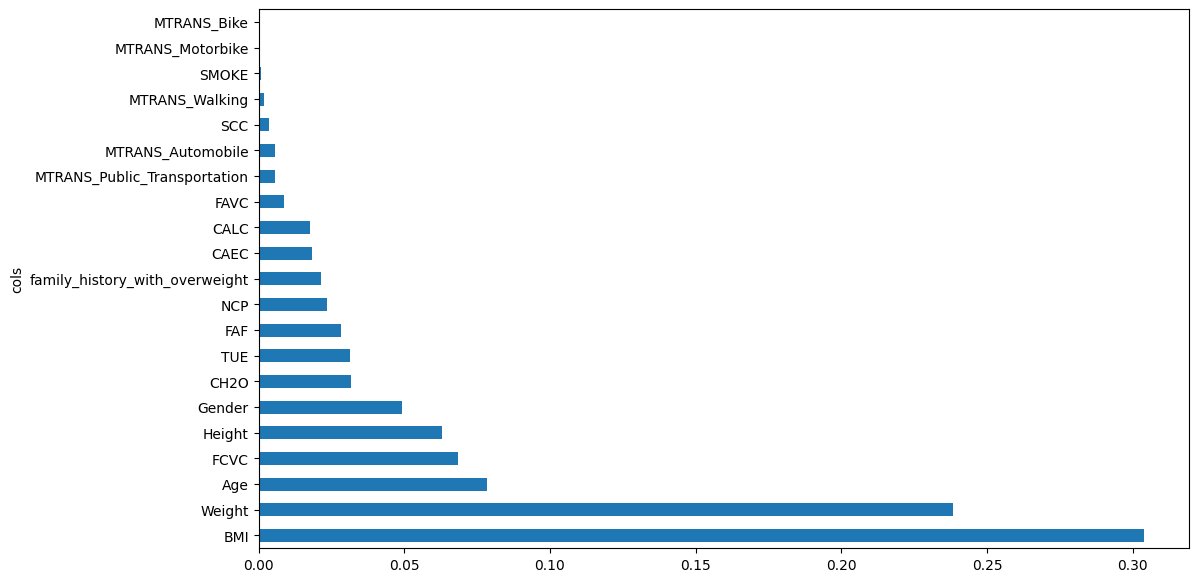

In [62]:
rf.fi()

In [65]:
rf2 = learner(train,test,target,RandomForestClassifier(),['Weight','BMI','Gender','Height','FCVC','Age','CALC', 'CAEC', 'NCP', 'FAF', 'TUE', 'CH2O','family_history_with_overweight'],'BasicRF-2 cols')
rf2.fit()

---------------------------------------------------------------
Fold, 1, ==> BasicRF-2 cols oof ACC score is ==> 0.8988439306358381
---------------------------------------------------------------
Fold, 2, ==> BasicRF-2 cols oof ACC score is ==> 0.8925818882466281
---------------------------------------------------------------
Fold, 3, ==> BasicRF-2 cols oof ACC score is ==> 0.903179190751445
---------------------------------------------------------------
Fold, 4, ==> BasicRF-2 cols oof ACC score is ==> 0.8947241628523247
---------------------------------------------------------------
Fold, 5, ==> BasicRF-2 cols oof ACC score is ==> 0.8952059744639845
---------------------------------------------------------------
Average Accuracy of model is: 0.8969070293900441
-------------------------------------------------------------
                   avgAcc
BasicRF-Allcols  0.901917
BasicRF-2 cols   0.896907


In [18]:
nfolds = 5
skfold = StratifiedKFold(n_splits=nfolds,shuffle=True,random_state=0)

X=train[cols]
y=train[target]


def rf_objective(trial):

        # Set the hyperparameters of the XGBoost classifier.
        params = { 
            'n_estimators' : trial.suggest_int("n_estimators", 100, 500, 25),
            'max_depth' : trial.suggest_int("max_depth", 2, 15),
            'min_samples_split' : trial.suggest_int("min_samples_split", 10, 300,10),
            'min_samples_leaf' : trial.suggest_int("min_samples_leaf", 5, 300,10),
            'max_features':trial.suggest_float('max_features',0.01,1),
            'n_jobs':-1
            }
        
        rf_acc_score_avg = 0
        
        for idx, (train_idx,val_idx) in enumerate(skfold.split(X,y)):
            train_X = X.iloc[train_idx]
            val_X = X.iloc[val_idx]
            train_y = y[train_idx]
            val_y = y[val_idx]

            rf_model = RandomForestClassifier(**params)

            rf_model.fit(train_X,train_y)

            rf_prediction = rf_model.predict(val_X)
            rf_acc_score = accuracy_score(val_y, rf_prediction)
#             print(f'The AUC score evaluated on the validation subset using XGB model for fold {idx}: ', xgb_auc_score)

            rf_acc_score_avg += rf_acc_score
            
        rf_acc_score_avg /=nfolds
#         print(f'The averaged AUC score evaluated on the validation subset using XGB model:', rf_auc_score_avg)
        return -rf_acc_score_avg

In [75]:
rf_study = optuna.create_study()
rf_study.optimize(rf_objective, n_trials=50,show_progress_bar=True)
best_rf_params = rf_study.best_trial.params
print('Best RF hyper parameters:', best_rf_params)

[I 2024-02-10 02:38:08,007] A new study created in memory with name: no-name-caace157-e085-40f6-86b7-65a5c940c274


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2024-02-10 02:38:28,057] Trial 0 finished with value: -0.8720496581597674 and parameters: {'n_estimators': 475, 'max_depth': 7, 'min_samples_split': 40, 'min_samples_leaf': 95, 'max_features': 0.40921375642163305}. Best is trial 0 with value: -0.8720496581597674.
[I 2024-02-10 02:38:34,691] Trial 1 finished with value: -0.5400329980611491 and parameters: {'n_estimators': 325, 'max_depth': 2, 'min_samples_split': 160, 'min_samples_leaf': 125, 'max_features': 0.025972724235458232}. Best is trial 0 with value: -0.8720496581597674.
[I 2024-02-10 02:38:48,680] Trial 2 finished with value: -0.878264215647366 and parameters: {'n_estimators': 175, 'max_depth': 13, 'min_samples_split': 150, 'min_samples_leaf': 25, 'max_features': 0.676363715421211}. Best is trial 2 with value: -0.878264215647366.
[I 2024-02-10 02:38:54,117] Trial 3 finished with value: -0.6894685056274017 and parameters: {'n_estimators': 250, 'max_depth': 12, 'min_samples_split': 150, 'min_samples_leaf': 295, 'max_features':

In [82]:
xgb = learner(train,test,target,XGBClassifier(),cols,'BasicXGBallCols')
xgb.fit()

---------------------------------------------------------------
Fold, 1, ==> BasicXGBallCols oof ACC score is ==> 0.9007707129094412
---------------------------------------------------------------
Fold, 2, ==> BasicXGBallCols oof ACC score is ==> 0.9029383429672447
---------------------------------------------------------------
Fold, 3, ==> BasicXGBallCols oof ACC score is ==> 0.9125722543352601
---------------------------------------------------------------
Fold, 4, ==> BasicXGBallCols oof ACC score is ==> 0.8993013731630932
---------------------------------------------------------------
Fold, 5, ==> BasicXGBallCols oof ACC score is ==> 0.9050831125030113
---------------------------------------------------------------
Average Accuracy of model is: 0.9041331591756101
-------------------------------------------------------------
                   avgAcc
BasicRF-Allcols  0.901917
BasicRF-2 cols   0.896907
BasicXGBallCols  0.904133


In [77]:
xgb.subm('basicXGBAllCols')

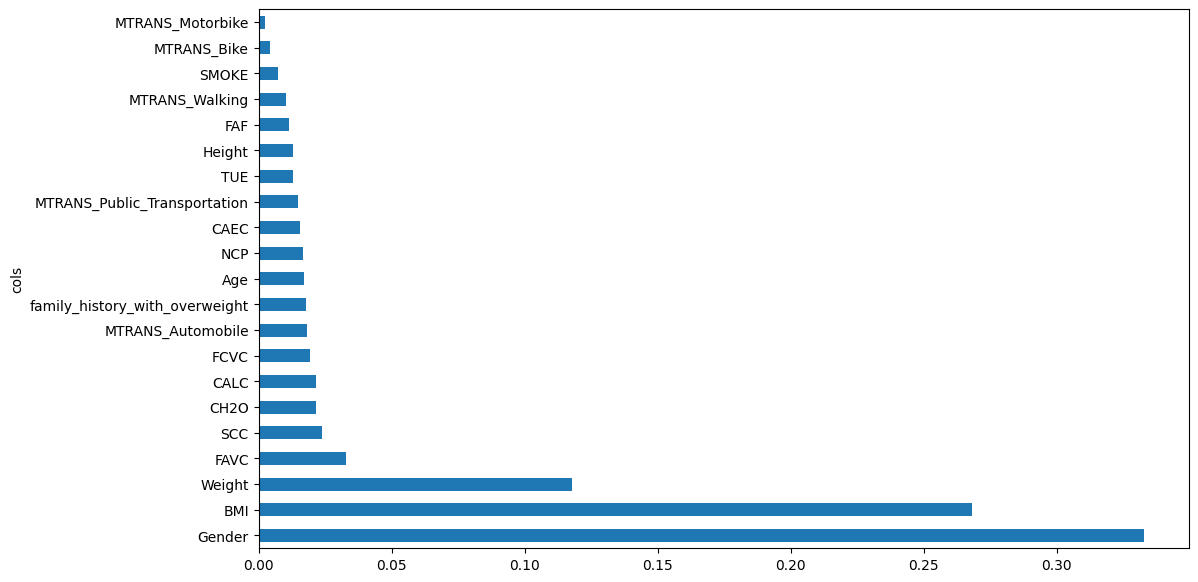

In [79]:
xgb.fi()

In [21]:
def xgb_objective(trial):

        # Set the hyperparameters of the XGBoost classifier.
        params = {'objective':'binary:logistic', 
                  'n_estimators': trial.suggest_int('n_estimators', 20, 1000, 25),
                  'learning_rate':trial.suggest_loguniform('learning_rate',0.0001,0.5),
                  'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                  'max_depth': trial.suggest_int('max_depth', 2, 15),
                  'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
                  'random_state':0,
#                   'subsample': trial.suggest_discrete_uniform('subsample', 0.6, 1.0, 0.05),
                  'subsample': trial.suggest_loguniform('subsample', 0.3, 0.9),
                  'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0),
                  'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 1.0),
                 }
        
        xgb_acc_score_avg = 0
        for idx, (train_idx,val_idx) in enumerate(skfold.split(X,y)):
            train_X = X.iloc[train_idx]
            val_X = X.iloc[val_idx]
            train_y = y[train_idx]
            val_y = y[val_idx]

            xgb_model = XGBClassifier(**params, n_jobs=-1)

            xgb_model.fit(train_X,train_y)

            xgb_prediction = xgb_model.predict(val_X)
            xgb_acc_score = accuracy_score(val_y, xgb_prediction)
#             print(f'The AUC score evaluated on the validation subset using XGB model for fold {idx}: ', xgb_auc_score)

            xgb_acc_score_avg += xgb_acc_score
            
        xgb_acc_score_avg /=nfolds
        print(f'The averaged AUC score evaluated on the validation subset using XGB model:', xgb_acc_score_avg)
        return -xgb_acc_score_avg

In [24]:
xgb_study = optuna.create_study()
xgb_study.optimize(xgb_objective, n_trials=100,show_progress_bar=True)
best_xgb_params = xgb_study.best_trial.params

print('Best XGB hyper parameters:', best_xgb_params)

[I 2024-02-11 04:09:20,524] A new study created in memory with name: no-name-15d7cefd-8c7a-483f-a353-1c1ad61f8003


  0%|          | 0/100 [00:00<?, ?it/s]

The averaged AUC score evaluated on the validation subset using XGB model: 0.8763855100959956
[I 2024-02-11 04:09:49,028] Trial 0 finished with value: -0.8763855100959956 and parameters: {'n_estimators': 395, 'learning_rate': 0.00010546867759007822, 'min_child_weight': 7, 'max_depth': 6, 'gamma': 1.2897291421857019e-05, 'subsample': 0.4928475850782313, 'reg_alpha': 0.4955037214763665, 'reg_lambda': 0.590940947528241}. Best is trial 0 with value: -0.8763855100959956.
The averaged AUC score evaluated on the validation subset using XGB model: 0.8823590109215275
[I 2024-02-11 04:10:31,333] Trial 1 finished with value: -0.8823590109215275 and parameters: {'n_estimators': 520, 'learning_rate': 0.0003258316398206944, 'min_child_weight': 9, 'max_depth': 7, 'gamma': 9.780647927450727e-06, 'subsample': 0.792434231252361, 'reg_alpha': 0.11093290010430885, 'reg_lambda': 0.6348821713847618}. Best is trial 1 with value: -0.8823590109215275.
The averaged AUC score evaluated on the validation subset u

In [25]:
XGBparams = {'n_estimators': 870, 'learning_rate': 0.041191805544577687, 'min_child_weight': 10, 'max_depth': 4, 'gamma': 0.001026902501620727, 'subsample': 0.645711725393614, 'reg_alpha': 0.7131791055459722, 'reg_lambda': 0.7147332494734335}
xgb2 = learner(train,test,target,XGBClassifier(**XGBparams),cols,'TunedXGBallCols')
xgb2.fit()

---------------------------------------------------------------
Fold, 1, ==> TunedXGBallCols oof ACC score is ==> 0.9063102119460501
---------------------------------------------------------------
Fold, 2, ==> TunedXGBallCols oof ACC score is ==> 0.9089595375722543
---------------------------------------------------------------
Fold, 3, ==> TunedXGBallCols oof ACC score is ==> 0.9171483622350675
---------------------------------------------------------------
Fold, 4, ==> TunedXGBallCols oof ACC score is ==> 0.9050831125030113
---------------------------------------------------------------
Fold, 5, ==> TunedXGBallCols oof ACC score is ==> 0.906046735726331
---------------------------------------------------------------
Average Accuracy of model is: 0.9087095919965428
-------------------------------------------------------------
                  avgAcc
TunedXGBallCols  0.90871


In [26]:
xgb2.subm('tunedXGBAllCols')

In [28]:
lgb = learner(train,test,target,LGBMClassifier(),cols,'BasicLGBallCols')
lgb.fit()

---------------------------------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003610 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2303
[LightGBM] [Info] Number of data points in the train set: 16606, number of used features: 21
[LightGBM] [Info] Start training from score -2.108153
[LightGBM] [Info] Start training from score -1.907167
[LightGBM] [Info] Start training from score -2.107657
[LightGBM] [Info] Start training from score -1.635117
[LightGBM] [Info] Start training from score -1.855022
[LightGBM] [Info] Start training from score -2.146046
[LightGBM] [Info] Start training from score -1.964755
Fold, 1, ==> BasicLGBallCols oof ACC score is ==> 0.9034200385356455
---------------------------------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead o

In [29]:
lgb.subm('BasicLGBallCols')

In [37]:
def lgb_objective(trial):

        # Set the hyperparameters of the XGBoost classifier.
        params = {
        # "device_type": trial.suggest_categorical("device_type", ['gpu']),
            'n_estimators': trial.suggest_int('n_estimators', 20, 1000, 25),
#             "n_estimators": trial.suggest_categorical("n_estimators", [10000]),
            "learning_rate": trial.suggest_loguniform("learning_rate", 0.0001, 0.5),
            "num_leaves": trial.suggest_int("num_leaves", 10, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "verbose":-1,
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 1000),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 15),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 15),
            "min_split_gain": trial.suggest_float("min_split_gain", 0, 15),
            "subsample": trial.suggest_float(
                "subsample", 0.2, 0.95, step=0.1
            ),
            "subsample_freq": trial.suggest_categorical("subsample_freq", [1]),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.2, 0.95, step=0.1
            ),
            "boosting_type": "gbdt",
            "objective": "multiclass",          # Objective function for the model
            "metric": "multi_logloss", 
        }
            
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1121218)

        cv_scores = np.empty(5)
        
        for idx, (train_idx,val_idx) in enumerate(cv.split(X,y)):
            train_X = X.iloc[train_idx]
            val_X = X.iloc[val_idx]
            train_y = y[train_idx]
            val_y = y[val_idx]

            lgb_model = LGBMClassifier(**params)

            lgb_model.fit(train_X,
                          train_y,
#                           eval_set=[(val_X,val_y)],
#                           eval_metric=accuracy_score,
#                           early_stopping_rounds=100,
#                           callbacks=[
#                               LightGBMPruningCallback(trial,accuracy_score)
#                           ],
                         )

            lgb_prediction = lgb_model.predict(val_X)
            cv_scores[idx] = accuracy_score(val_y, lgb_prediction)

        return -np.mean(cv_scores)

In [41]:
lgbstudy = optuna.create_study( study_name="LGBM Classifier")
lgbstudy.optimize(lgb_objective, n_trials=200,show_progress_bar=True)
best_lgb_params = lgbstudy.best_trial.params

print('Best LGB hyper parameters:', best_lgb_params)

[I 2024-02-11 09:05:26,234] A new study created in memory with name: LGBM Classifier


  0%|          | 0/200 [00:00<?, ?it/s]

[W 2024-02-11 09:05:27,502] Trial 0 failed with parameters: {'n_estimators': 120, 'learning_rate': 0.002398185922065606, 'num_leaves': 15, 'max_depth': 11, 'min_child_samples': 864, 'reg_alpha': 2.9648673861926595, 'reg_lambda': 0.8973629401237609, 'min_split_gain': 3.8623424141794116, 'subsample': 0.6000000000000001, 'subsample_freq': 1, 'colsample_bytree': 0.9} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/optuna/study/_optimize.py", line 200, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_34/166225040.py", line 40, in lgb_objective
    lgb_model.fit(train_X,
  File "/opt/conda/lib/python3.10/site-packages/lightgbm/sklearn.py", line 1187, in fit
    super().fit(
  File "/opt/conda/lib/python3.10/site-packages/lightgbm/sklearn.py", line 885, in fit
    self._Booster = train(
  File "/opt/conda/lib/python3.10/site-packages/lightgbm/engine.py", line 276, in train
    booster

KeyboardInterrupt: 

In [42]:
lgbParams = {'verbose': -1,'n_estimators': 770, 'learning_rate': 0.043402868843122715, 'num_leaves': 23, 'max_depth': 8, 'min_child_samples': 492, 'reg_alpha': 1.2631498340438563, 'reg_lambda': 11.852717693834709, 'min_split_gain': 0.018594652152949365, 'subsample': 0.7, 'subsample_freq': 1, 'colsample_bytree': 0.4}
lgb2 = learner(train,test,target,LGBMClassifier(**lgbParams),cols,'TunedLGBallCols')
lgb2.fit()

---------------------------------------------------------------
Fold, 1, ==> TunedLGBallCols oof ACC score is ==> 0.9063102119460501
---------------------------------------------------------------
Fold, 2, ==> TunedLGBallCols oof ACC score is ==> 0.9084778420038536
---------------------------------------------------------------
Fold, 3, ==> TunedLGBallCols oof ACC score is ==> 0.9157032755298651
---------------------------------------------------------------
Fold, 4, ==> TunedLGBallCols oof ACC score is ==> 0.9038785834738617
---------------------------------------------------------------
Fold, 5, ==> TunedLGBallCols oof ACC score is ==> 0.906046735726331
---------------------------------------------------------------
Average Accuracy of model is: 0.9080833297359924
-------------------------------------------------------------
                   avgAcc
TunedXGBallCols  0.908710
BasicXGBallCols  0.905771
BasicLGBallCols  0.905771
TunedLGBallCols  0.908083


In [43]:
lgb2.subm('TunedLGBallCols')